# Quantile crossing validation of GPQR models for H

This notebook visualizes quantile crossing from direct GPQR.

GPR and center-gap GPQR are not tested because they are mathematically immune to quantile crossing.

The result shows that direct GPQRs are susceptible to quantile crossing, which does not disappear through training.

Hence, direct GPQRs should be avoided for general purpose models.

In [ ]:
import sys
import os
import math

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load data

In [ ]:
from scripts.crossing import quantile_crossing

QUANTILES = torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95]).to(device)
CENTER_QUANTILE_INDEX = 2
NUM_LOWER_QUANTILES = 2
NUM_LATENTS = 3
NUM_LOWER_LATENTS = 1

N_EPOCHS = int(os.getenv("HEAVYEDGE_N_EPOCHS", 10000))

In [ ]:
X_train = pd.read_csv("../_temp/X.csv").drop(columns="Slurry").values
y_train = pd.read_csv("../_temp/y.csv")["phi"].values

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

X_scale = scaler.scale_
X_min = scaler.min_

In [ ]:
grid1 = np.meshgrid(
    np.linspace(0, 1, 10),
    np.linspace(0, 1, 10),
    np.unique(X_train[:, -1]),  # 4 unique values
    indexing="ij",
)
X_pred1 = np.stack(grid1, axis=-1).reshape(-1, X_train.shape[-1])

In [ ]:
grid2 = np.meshgrid(
    np.linspace(-2, 2, 20),
    np.linspace(-2, 2, 20),
    np.linspace(-2, 2, 20),
    indexing="ij",
)
X_pred2 = np.stack(grid2, axis=-1).reshape(-1, X_train.shape[-1])

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_scale = torch.tensor(X_scale, dtype=torch.float32).to(device)
X_min = torch.tensor(X_min, dtype=torch.float32).to(device)
X_pred1 = torch.tensor(X_pred1, dtype=torch.float32).to(device)
X_pred2 = torch.tensor(X_pred2, dtype=torch.float32).to(device)

## Direct LMC

In [ ]:
from scripts.all_models import DirectLmcMtgpqr_phi
from gpytorch_qr.likelihoods import MultitaskQuantileGPLikelihood

QC_PATH = "../_temp/direct_lmc_crossing.phi.csv"

if os.path.exists(QC_PATH):
    direct_lmc_qc = pd.read_csv(QC_PATH)
else:
    model = DirectLmcMtgpqr_phi(
        inducing_points=X_train.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=X_scale,
        X_min=X_min,
    ).to(device)
    likelihood = MultitaskQuantileGPLikelihood(
        QUANTILES,
        torch.zeros((len(QUANTILES),)),
        learn_scales=True,
    ).to(device)

    (cr1, cr2), (mc1, mc2), (mx1, mx2) = quantile_crossing(
        X_train,
        y_train,
        [X_pred1, X_pred2],
        model,
        likelihood,
        N_EPOCHS,
        learning_rate=0.001,
    )
    direct_lmc_qc = pd.DataFrame(
        {
            "crossing_rate_1": cr1,
            "crossing_rate_2": cr2,
            "mean_crossing_1": mc1,
            "mean_crossing_2": mc2,
            "max_crossing_1": mx1,
            "max_crossing_2": mx2,
        }
    )
    direct_lmc_qc.to_csv(QC_PATH, index=False)

## Direct independent

In [ ]:
from scripts.all_models import DirectIndependentMtgpqr_phi
from gpytorch_qr.likelihoods import MultitaskQuantileGPLikelihood

QC_PATH = "../_temp/direct_independent_crossing.phi.csv"

if os.path.exists(QC_PATH):
    direct_independent_qc = pd.read_csv(QC_PATH)
else:
    model = DirectIndependentMtgpqr_phi(
        inducing_points=X_train.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=X_scale,
        X_min=X_min,
    ).to(device)
    likelihood = MultitaskQuantileGPLikelihood(
        QUANTILES,
        torch.zeros((len(QUANTILES),)),
        learn_scales=True,
    ).to(device)

    (cr1, cr2), (mc1, mc2), (mx1, mx2) = quantile_crossing(
        X_train,
        y_train,
        [X_pred1, X_pred2],
        model,
        likelihood,
        N_EPOCHS,
        learning_rate=0.001,
    )
    direct_independent_qc = pd.DataFrame(
        {
            "crossing_rate_1": cr1,
            "crossing_rate_2": cr2,
            "mean_crossing_1": mc1,
            "mean_crossing_2": mc2,
            "max_crossing_1": mx1,
            "max_crossing_2": mx2,
        }
    )
    direct_independent_qc.to_csv(QC_PATH, index=False)

## Plot

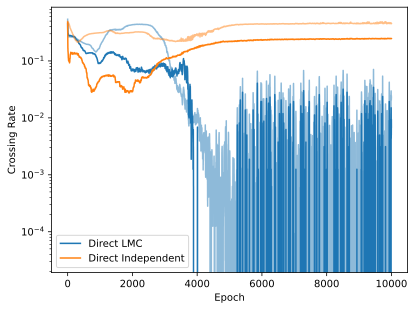

In [ ]:
plt.plot(direct_lmc_qc["crossing_rate_1"], color="tab:blue", label="Direct LMC")
plt.plot(direct_lmc_qc["crossing_rate_2"], color="tab:blue", alpha=0.5)
plt.plot(
    direct_independent_qc["crossing_rate_1"],
    color="tab:orange",
    label="Direct Independent",
)
plt.plot(direct_independent_qc["crossing_rate_2"], color="tab:orange", alpha=0.5)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Crossing Rate")
plt.legend()
plt.show()

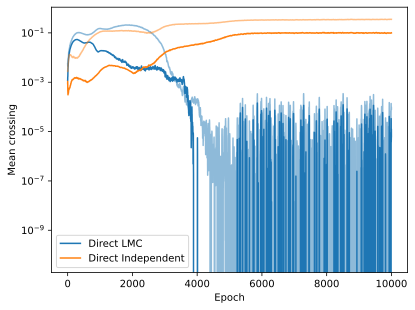

In [ ]:
plt.plot(direct_lmc_qc["mean_crossing_1"], color="tab:blue", label="Direct LMC")
plt.plot(direct_lmc_qc["mean_crossing_2"], color="tab:blue", alpha=0.5)
plt.plot(
    direct_independent_qc["mean_crossing_1"],
    color="tab:orange",
    label="Direct Independent",
)
plt.plot(direct_independent_qc["mean_crossing_2"], color="tab:orange", alpha=0.5)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Mean crossing")
plt.legend()
plt.show()

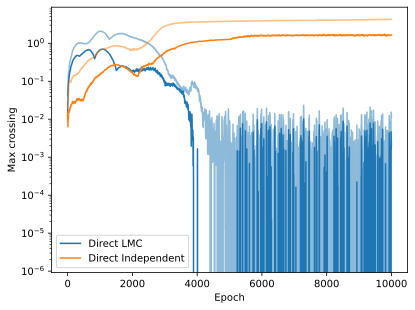

In [ ]:
plt.plot(direct_lmc_qc["max_crossing_1"], color="tab:blue", label="Direct LMC")
plt.plot(direct_lmc_qc["max_crossing_2"], color="tab:blue", alpha=0.5)
plt.plot(
    direct_independent_qc["max_crossing_1"],
    color="tab:orange",
    label="Direct Independent",
)
plt.plot(direct_independent_qc["max_crossing_2"], color="tab:orange", alpha=0.5)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Max crossing")
plt.legend()
plt.show()